Data sources: [US Mortality DataBase for the USA](https://usa.mortality.org/national.php?national=USA), [for California](https://usa.mortality.org/state.php?state=CA), [for New York](https://usa.mortality.org/state.php?state=NY) / [U.S State Life Tables CSV + TXT 1941-2022](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/19WYUX)<br>
Outputs placed to wiki:<br>
[List of U.S. states and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_life_expectancy#Data_of_the_United_States_Mortality_DataBase) <i>([alternative](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_U.S._states_and_territories_by_life_expectancy_(alternative)#Data_of_the_United_States_Mortality_DataBase))</i> / [Продолжительность жизни в штатах США](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_штатах_США#Данные_United_States_Mortality_DataBase)<br>
[Demographics of New York (state)](https://en.wikipedia.org/wiki/Demographics_of_New_York_(state)#Percentage_surviving), [Demographics of California](https://en.wikipedia.org/wiki/Demographics_of_California#Percentage_surviving), [Hawaii](https://en.wikipedia.org/wiki/Hawaii#Percentage_surviving)<br>
<br>
[chart from the National Vital Statisctics Reports](https://commons.wikimedia.org/wiki/File:Percentage_Surviving_to_Certain_Ages_in_the_U.S..png) at Wikimedia Commons<br>
[selection of colors](http://mal-bioit.ru/survey-web-colors)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
# import math
import re
from collections import namedtuple

# import sys
# sys.path.append("..")
# import mal_moduls_private.mal_total as mal

In [3]:
# pd.options.display.min_rows=4

In [4]:
LANG = 'en'
PERIOD = '2015-2019'
ST1 = 'NY'   # New York (state)
ST2 = 'CA'   # California
ST3 = 'HI'   # Hawaii

DESTINATION_CHART = 'show'  # to where the created charts should be placed: 'file', 'show'

In [5]:
def extract_LE_for_male_and_female_from_file(level, abbr, period, abbr_region):
    '''Extract automatically life expectancy for male and female in a given region'''
    df_m = pd.read_csv(f"data/{level}/{abbr}/{abbr}_mltper_1x5.csv", sep=',', usecols=['Year', 'Age', 'ex'])
    le_m = df_m.loc[(df_m['Year'] == period) & (df_m['Age'] == '0')] \
               .iloc[0] \
               .loc['ex']

    df_f = pd.read_csv(f"data/{level}/{abbr}/{abbr}_fltper_1x5.csv", sep=',', usecols=['Year', 'Age', 'ex'])
    le_f = df_f.loc[(df_f['Year'] == period) & (df_f['Age'] == '0')] \
               .iloc[0] \
               .loc['ex']

    print(f"{abbr_region:3}-  ♂: {le_m:.2f},   ♀: {le_f:.2f}")
    return le_m, le_f


le_m_country, le_f_country = extract_LE_for_male_and_female_from_file(level='Nationals', abbr='USA', period=PERIOD, abbr_region='USA')
le_m_st1, le_f_st1 = extract_LE_for_male_and_female_from_file(level='States', abbr=ST1, period=PERIOD, abbr_region=ST1)
le_m_st2, le_f_st2 = extract_LE_for_male_and_female_from_file(level='States', abbr=ST2, period=PERIOD, abbr_region=ST2)
le_m_st3, le_f_st3 = extract_LE_for_male_and_female_from_file(level='States', abbr=ST3, period=PERIOD, abbr_region=ST3)

USA-  ♂: 76.25,   ♀: 81.22
NY -  ♂: 78.29,   ♀: 83.07
CA -  ♂: 78.54,   ♀: 83.26
HI -  ♂: 78.59,   ♀: 84.42


In [7]:
def load_data_single_unit(level, abbr, period, suffix_for_columns=''):  # , level='Nationals' / 'States'
    '''This function load data for percentage surviving for a single state or a country as a whole'''
    df_m = pd.read_csv(f"data/{level}/{abbr}/{abbr}_mltper_1x5.csv", sep=',', usecols=['Year', 'Age', 'lx'])
    df_m = df_m.loc[df_m['Year'] == period] \
               .drop(columns='Year') \
               .set_index('Age')
    df_m = df_m.rename(index={'110+': '110'}).rename(index=lambda st: int(st))
    
    df_t = pd.read_csv(f"data/{level}/{abbr}/{abbr}_bltper_1x5.csv", sep=',', usecols=['Year', 'Age', 'lx'])
    df_t = df_t.loc[df_t['Year'] == period] \
               .drop(columns='Year') \
               .set_index('Age')
    df_t = df_t.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_f = pd.read_csv(f"data/{level}/{abbr}/{abbr}_fltper_1x5.csv", sep=',', usecols=['Year', 'Age', 'lx'])
    df_f = df_f.loc[df_f['Year'] == period] \
               .drop(columns='Year') \
               .set_index('Age')
    df_f = df_f.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('males', 'total', 'females')

    df['fΔm'] = df['females'] - df['males']     # No requirement for rounding since numbers are integers
    df['ratio_fm'] = (df['females'] / df['males']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]

    return df


df = pd.concat([
        load_data_single_unit(level='Nationals', abbr='USA', period=PERIOD),
        load_data_single_unit(level='States', abbr=ST1, period=PERIOD, suffix_for_columns="_st1"),
        load_data_single_unit(level='States', abbr=ST2, period=PERIOD, suffix_for_columns="_st2"),
        load_data_single_unit(level='States', abbr=ST3, period=PERIOD, suffix_for_columns="_st3")], axis='columns')

df.loc[[0, 1, 5]+list(range(100, 111))]

,males,total,females,fΔm,ratio_fm,males_st1,total_st1,females_st1,fΔm_st1,ratio_fm_st1,males_st2,total_st2,females_st2,fΔm_st2,ratio_fm_st2,males_st3,total_st3,females_st3,fΔm_st3,ratio_fm_st3
,,,,,,,,,,,,,,,,,,,,
0,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00
1,99378,99430,99483,105,1.00,99525,99562,99601,76,1.00,99548,99585,99623,75,1.00,99352,99423,99499,147,1.00
5,99270,99332,99398,128,1.00,99451,99491,99534,83,1.00,99471,99515,99561,90,1.00,99250,99335,99425,175,1.00
100,1069,2067,2912,1843,2.72,1491,2995,4135,2644,2.77,1662,2965,4093,2431,2.46,2319,4628,6649,4330,2.87
101,683,1391,1985,1302,2.91,967,2069,2895,1928,2.99,1091,2040,2859,1768,2.62,1549,3262,4769,3220,3.08
102,422,906,1310,888,3.10,606,1384,1962,1356,3.24,693,1359,1933,1240,2.79,999,2222,3304,2305,3.31
103,252,570,835,583,3.31,367,895,1285,918,3.50,425,876,1263,838,2.97,622,1461,2208,1586,3.55
104,145,347,514,369,3.54,214,560,814,600,3.80,252,545,798,546,3.17,373,926,1422,1049,3.81
105,81,204,306,225,3.78,121,338,497,376,4.11,144,328,486,342,3.38,216,565,881,665,4.08


In [8]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(100, 111)), ['males', 'males_st1', 'males_st2', 'males_st3', 'females', 'females_st1', 'females_st2', 'females_st3']]

,males,males_st1,males_st2,males_st3,females,females_st1,females_st2,females_st3
,,,,,,,,
0,100000,100000,100000,100000,100000,100000,100000,100000
1,99378,99525,99548,99352,99483,99601,99623,99499
5,99270,99451,99471,99250,99398,99534,99561,99425
100,1069,1491,1662,2319,2912,4135,4093,6649
101,683,967,1091,1549,1985,2895,2859,4769
102,422,606,693,999,1310,1962,1933,3304
103,252,367,425,622,835,1285,1263,2208
104,145,214,252,373,514,814,798,1422
105,81,121,144,216,306,497,486,881


<br>
<br>

In [10]:
# Code in this cell generates an extended table about percentage surviving in the United States as a whole and states
# (by default, these are New York and California)

def create_table_extended(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x/1000:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in [1] + list(range(5, 111, 5)):
        ser = df.iloc[i]
        age = ser.name

        if age < 100:
            prec = 1
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_st1'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_st1'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st1']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_st2'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_st2'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st2']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_st3'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_st3'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st3']:0.2f}'
        else:
            prec = 3
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_st1'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_st1'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st1']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_st2'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_st2'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st2']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_st3'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_st3'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_st3']:0.2f}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st


table_code = create_table_extended(df, file_header='Perc_surviving_header_extended -ru.txt', lang='ru')
with open('output/Table code for percentage surviving extended, 5 years average -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

table_code = create_table_extended(df, file_header='Perc_surviving_header_extended -en.txt', lang='en')
with open('output/Table code for percentage surviving extended, 5 years average -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

<br>
<br>

In [12]:
# This function generates a simple table about percentage surviving in the country as a whole or in a single state

def create_table_region(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x/1000:0.{prec}f}"


    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in [1] + list(range(5, 111, 5)):
        ser = df.iloc[i]
        age = ser.name

        if age < 100:
            prec = 1
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f}'
        else:
            prec = 3
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st


# generate a simple table about percentage surviving in the United States as a whole
table_code = create_table_region(df[['males', 'total', 'females', 'fΔm', 'ratio_fm']],
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open('output/Table code for percentage surviving simple, 5 years average -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males', 'total', 'females', 'fΔm', 'ratio_fm']],
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open('output/Table code for percentage surviving simple, 5 years average -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

In [13]:
# generate a simple table about percentage surviving in the first state (by default, this is New York)
table_code = create_table_region(df[['males_st1', 'total_st1', 'females_st1', 'fΔm_st1', 'ratio_fm_st1']] \
                                   .rename(columns={'males_st1': 'males', 'total_st1': 'total', 'females_st1': 'females', 'fΔm_st1': 'fΔm', 'ratio_fm_st1': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open(f'output/Table code for percentage surviving, 5 years average -{ST1} -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males_st1', 'total_st1', 'females_st1', 'fΔm_st1', 'ratio_fm_st1']] \
                                   .rename(columns={'males_st1': 'males', 'total_st1': 'total', 'females_st1': 'females', 'fΔm_st1': 'fΔm', 'ratio_fm_st1': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open(f'output/Table code for percentage surviving, 5 years average -{ST1} -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

In [14]:
# generate a simple table about percentage surviving in the second state (by default, this is California)
table_code = create_table_region(df[['males_st2', 'total_st2', 'females_st2', 'fΔm_st2', 'ratio_fm_st2']] \
                                   .rename(columns={'males_st2': 'males', 'total_st2': 'total', 'females_st2': 'females', 'fΔm_st2': 'fΔm', 'ratio_fm_st2': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open(f'output/Table code for percentage surviving, 5 years average -{ST2} -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males_st2', 'total_st2', 'females_st2', 'fΔm_st2', 'ratio_fm_st2']] \
                                   .rename(columns={'males_st2': 'males', 'total_st2': 'total', 'females_st2': 'females', 'fΔm_st2': 'fΔm', 'ratio_fm_st2': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open(f'output/Table code for percentage surviving, 5 years average -{ST2} -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

In [15]:
# generate a simple table about percentage surviving in the third state (by default, this is Hawaii)
table_code = create_table_region(df[['males_st3', 'total_st3', 'females_st3', 'fΔm_st3', 'ratio_fm_st3']] \
                                   .rename(columns={'males_st3': 'males', 'total_st3': 'total', 'females_st3': 'females', 'fΔm_st3': 'fΔm', 'ratio_fm_st3': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -en.txt', lang='en')
with open(f'output/Table code for percentage surviving, 5 years average -{ST3} -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_region(df[['males_st3', 'total_st3', 'females_st3', 'fΔm_st3', 'ratio_fm_st3']] \
                                   .rename(columns={'males_st3': 'males', 'total_st3': 'total', 'females_st3': 'females', 'fΔm_st3': 'fΔm', 'ratio_fm_st3': 'ratio_fm'}),
                                 file_header='Perc_surviving_header -ru.txt', lang='ru')
with open(f'output/Table code for percentage surviving, 5 years average -{ST3} -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

<br>
<br>

In [17]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'color', 'style', 'width', 'alpha'])

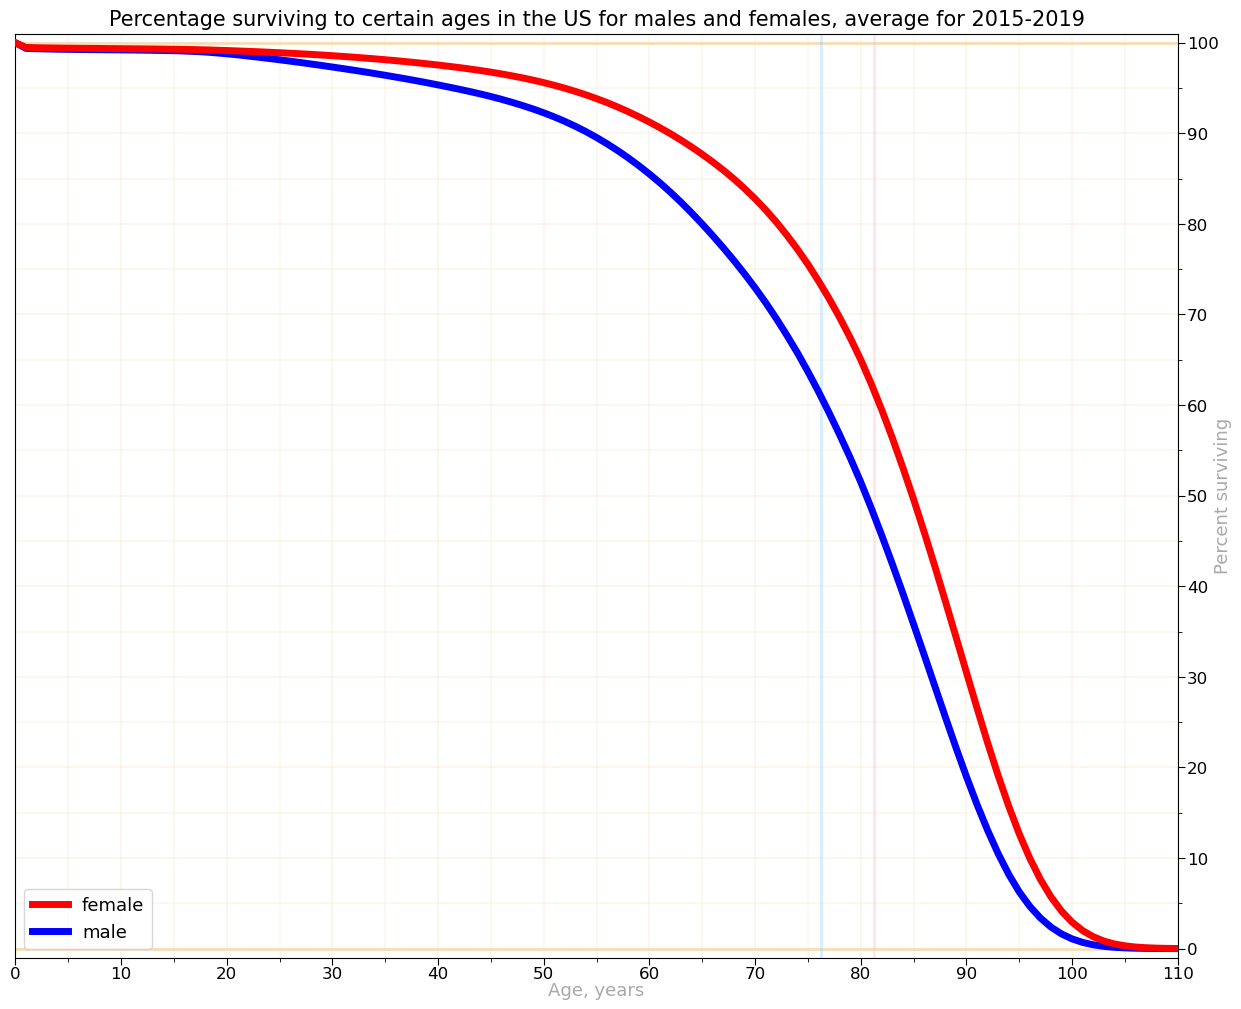

In [18]:
def create_chart(
        df, lang=LANG, dd_display='', ncol=2,
        title_en='Title of the chart', title_ru='Заголовок графика',
        le_male=None, le_female=None,
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (16, 12.5) if lang=='ru' else (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()  # show ticks only at the left side
    ax.yaxis.set_label_position("right")  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=3)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=3)  # Minor ticks are shorter
    plt.xticks(fontsize=12)  # font size for tick labels
    plt.yticks(fontsize=12)
    
    x_min = y_min = 0
    x_max = 110
    y_max = 100
    plt.xlim(0, 110)
    plt.ylim(-1, 101)

    # for version with ratio
    # labels_y = range(y_min, y_max+1, 10)
    # y_labels_names = ((f"{v/100:.1f}" if v % 100 != 0  else v//100) for v in labels_y)
    # plt.yticks(labels_y, labels=y_labels_names)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.3)

    plt.axhline(y=100, color='wheat', linewidth=2)
    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=15)
    plt.xlabel('Возраст, годы' if lang=='ru' else 'Age, years', fontsize=13, color='darkgray', labelpad=-0.5)
    plt.ylabel('Процент выживших' if lang=='ru' else 'Percent surviving', fontsize=13, color='darkgray', labelpad=-3.5)
    # plt.ylabel('Доля выживших' if lang=='ru' else 'Survival Rate', fontsize=13, color='darkgray')  # , labelpad=-2

    if le_male:
        plt.axvline(x=le_male, color='lightskyblue', linewidth=2, alpha=0.35)
    if le_female:
        plt.axvline(x=le_female, color='lightpink', linewidth=2, alpha=0.35)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='lower left', fontsize=13, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()


dd_display = {
    'females'       : DisplayedGroup(en_name='female',      ru_name='женщины',         color='red',  style='-',  width=5, alpha=1),
    # 'all_t'       : DisplayedGroup(en_name='Population Overall', ru_name='население в целом',       color='lightgrey',  style='-',  width=6, alpha=1),
    'males'       : DisplayedGroup(en_name='male',    ru_name='мужчины',         color='blue',  style='-', width=5, alpha=1),
}

create_chart(df.T.loc[['females', 'males']] / 1000,
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en=f'Percentage surviving to certain ages in the US for males and females, average for {PERIOD}',  # , overall statistics for males and females
             title_ru=f'Процент выживших к определённому возрасту в США для мужчин и женщин, {PERIOD}',
             le_male=le_m_country, le_female=le_f_country,
             file_name='Percentage Surviving to Certain Ages in the US by USMDB 5 years average')

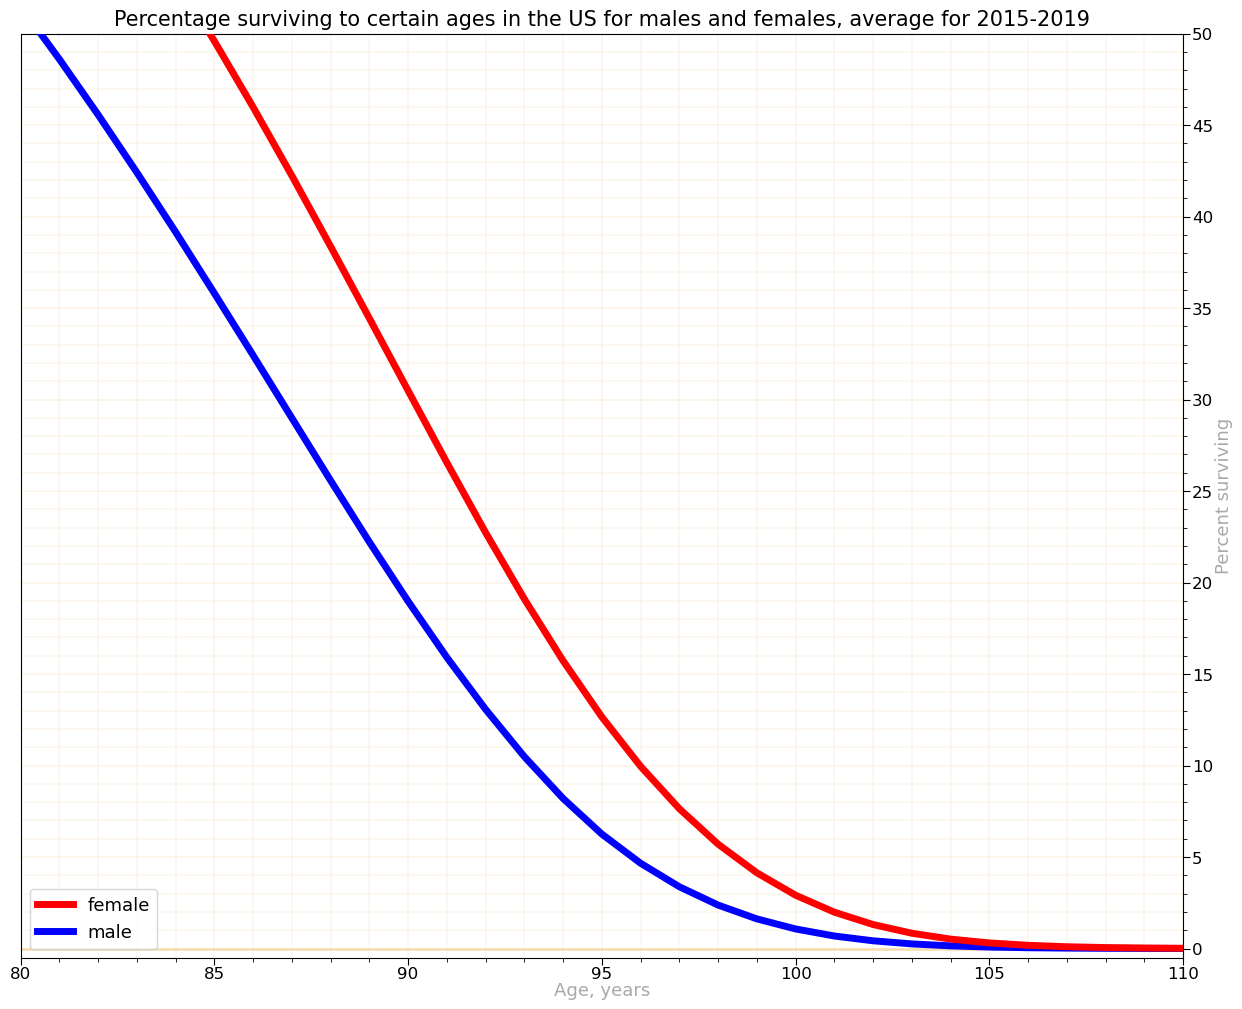

In [19]:
def create_chart_zoomed(
        df, lang=LANG, dd_display='', ncol=2,
        title_en='Title of the chart', title_ru='Заголовок графика',
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (16, 12.5) if lang=='ru' else (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()  # show ticks only at the left side
    ax.yaxis.set_label_position("right")  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(5))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(1))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=3)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=3)  # Minor ticks are shorter
    plt.xticks(fontsize=12)  # font size for tick labels
    plt.yticks(fontsize=12)
    
    x_min = y_min = 0
    x_max = 110
    y_max = 100
    plt.xlim(80, 110)
    plt.ylim(-0.5, 50)

    # for version with ratio
    # labels_y = range(y_min, y_max+1, 10)
    # y_labels_names = ((f"{v/100:.1f}" if v % 100 != 0  else v//100) for v in labels_y)
    # plt.yticks(labels_y, labels=y_labels_names)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.3)

    # plt.axhline(y=100, color='wheat', linewidth=2)
    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=15)
    plt.xlabel('Возраст, годы' if lang=='ru' else 'Age, years', fontsize=13, color='darkgray', labelpad=-0.5)
    plt.ylabel('Процент выживших' if lang=='ru' else 'Percent surviving', fontsize=13, color='darkgray', labelpad=1)
    # plt.ylabel('Доля выживших' if lang=='ru' else 'Survival Rate', fontsize=13, color='darkgray')  # , labelpad=-2
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='lower left', fontsize=13, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()


dd_display = {
    'females'       : DisplayedGroup(en_name='female',      ru_name='женщины',         color='red',  style='-',  width=5, alpha=1),
    # 'all_t'       : DisplayedGroup(en_name='Population Overall', ru_name='население в целом',       color='lightgrey',  style='-',  width=6, alpha=1),
    'males'       : DisplayedGroup(en_name='male',    ru_name='мужчины',         color='blue',  style='-', width=5, alpha=1),
}

create_chart_zoomed(df.T.loc[['females', 'males']] / 1000,
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en=f'Percentage surviving to certain ages in the US for males and females, average for {PERIOD}',  # , overall statistics for males and females
             title_ru=f'Процент выживших к определённому возрасту в США для мужчин и женщин, {PERIOD}',
             file_name='Percentage Surviving to Certain Ages in the US by USMDB 5 years average -zoomed')

<br>

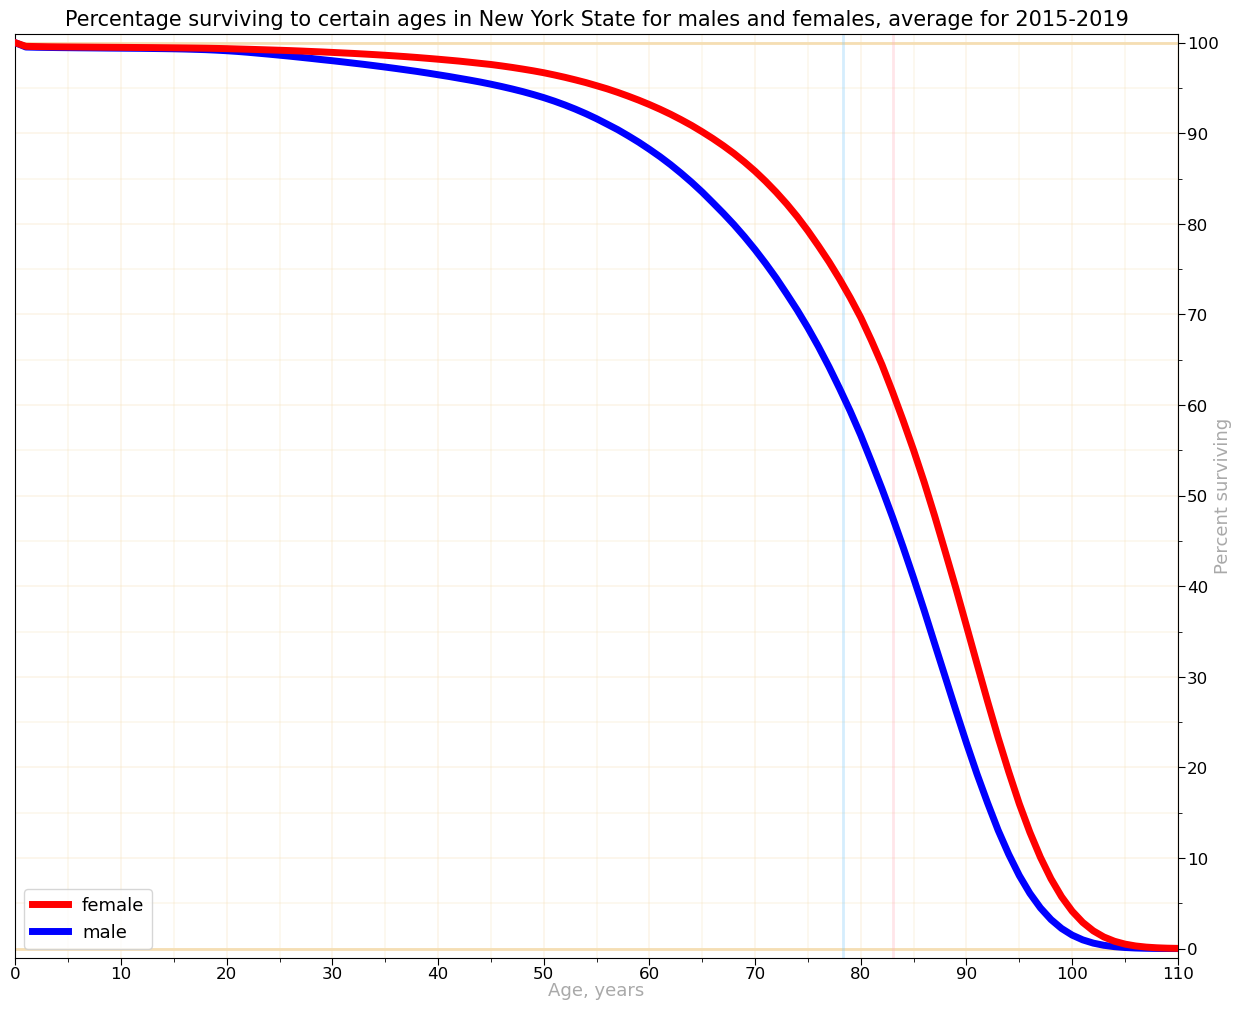

In [21]:
# chart for New York State

if ST1 == 'NY':
    create_chart(df.T.loc[['females_st1', 'males_st1']] \
                   .rename(index={'females_st1': 'females', 'males_st1': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f'Percentage surviving to certain ages in New York State for males and females, average for {PERIOD}',
                 title_ru=f'Процент выживших к определённому возрасту в штате Нью-Йорк для мужчин и женщин, {PERIOD}',
                 le_male=le_m_st1, le_female=le_f_st1,
                 file_name='Percentage Surviving to Certain Ages in New York State 5 years average')

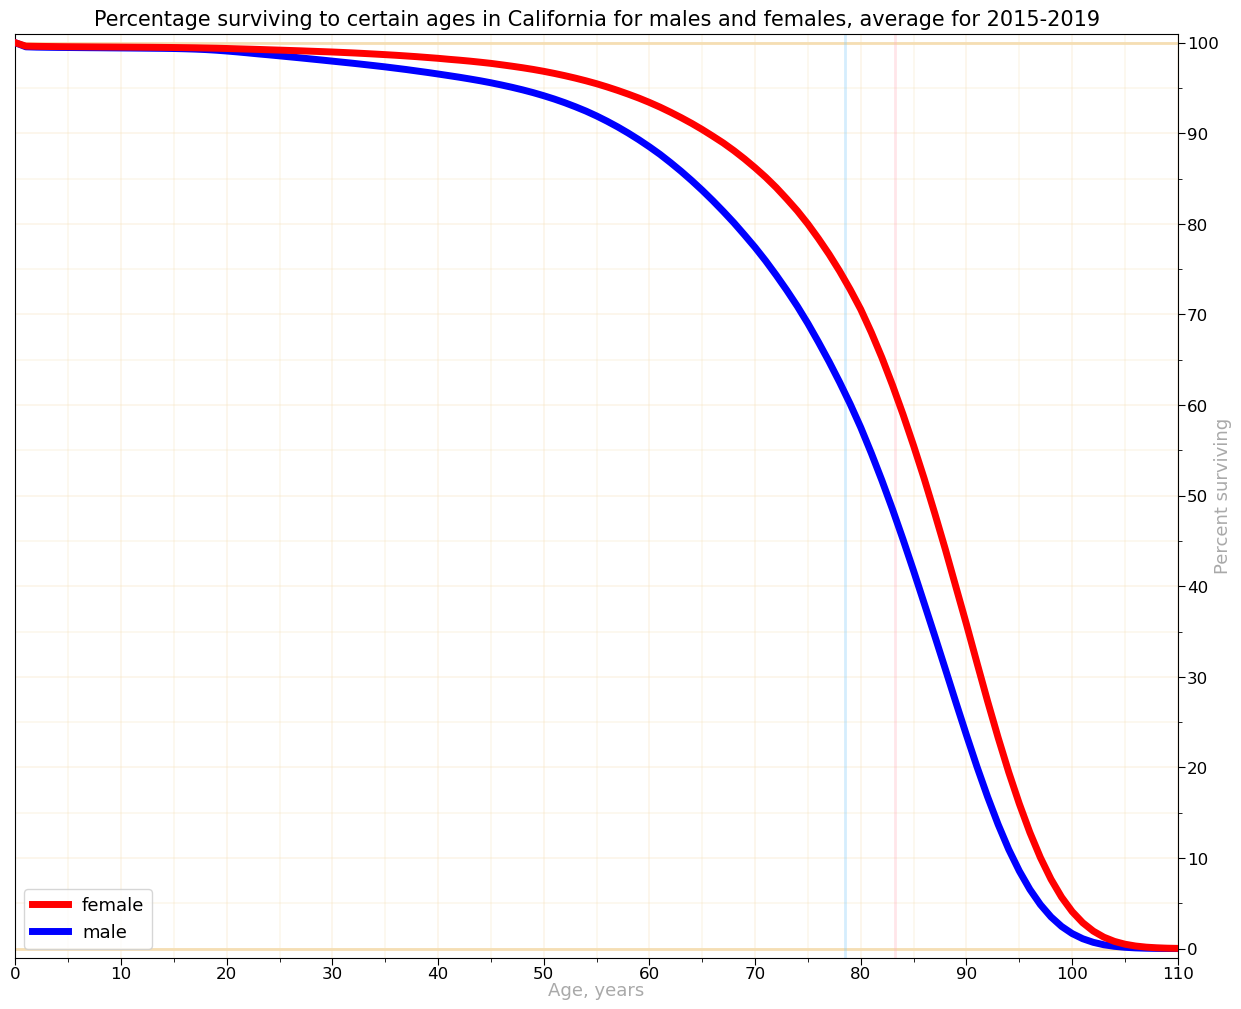

In [22]:
# chart for California

if ST2 == 'CA':
    create_chart(df.T.loc[['females_st2', 'males_st2']] \
                   .rename(index={'females_st2': 'females', 'males_st2': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f'Percentage surviving to certain ages in California for males and females, average for {PERIOD}',
                 title_ru=f'Процент выживших к определённому возрасту в Калифорнии для мужчин и женщин, {PERIOD}',
                 le_male=le_m_st2, le_female=le_f_st2,
                 file_name='Percentage Surviving to Certain Ages in California 5 years average')

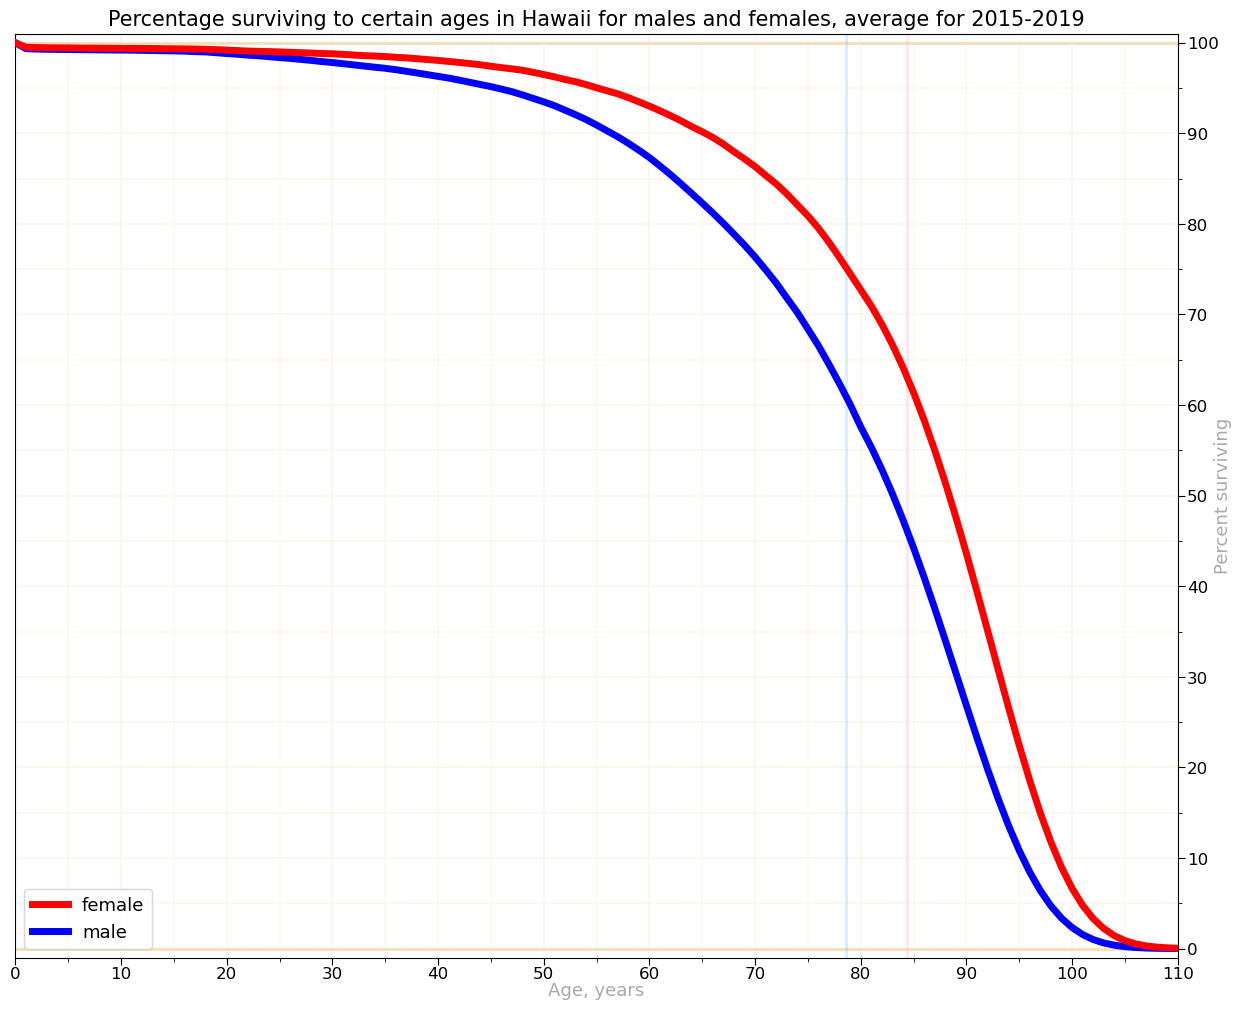

In [23]:
# chart for Hawaii

if ST3 == 'HI':
    create_chart(df.T.loc[['females_st3', 'males_st3']] \
                   .rename(index={'females_st3': 'females', 'males_st3': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f'Percentage surviving to certain ages in Hawaii for males and females, average for {PERIOD}',
                 title_ru=f'Процент выживших к определённому возрасту на Гавайях для мужчин и женщин, {PERIOD}',
                 le_male=le_m_st3, le_female=le_f_st3,
                 file_name='Percentage Surviving to Certain Ages in Hawaii 5 years average')